# Bearing Autoencoder — PER ASSET EXPERIMENT

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path
from collections import deque

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from sklearn.svm import OneClassSVM
from sklearn.covariance import EllipticEnvelope

from sklearn.pipeline import Pipeline

import pandas as pd
import numpy as np
from datetime import datetime

In [2]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model

GLOBAL_SEED = 42
np.random.seed(GLOBAL_SEED)
tf.random.set_seed(GLOBAL_SEED)
print('TF version:', tf.__version__)

TF version: 2.16.2


In [3]:
data_root = Path("../NASA_Bearing/IMS")

In [30]:
NASA_IMS_CHANNELS = {
    # Experiment 1: two channels per bearing
    1: {
        1: (0, 1),
        2: (2, 3),
        3: (4, 5),
        4: (6, 7),
    },

    # Experiments 2 and 3: one channel per bearing
    2: {
        1: (0,),
        2: (1,),
        3: (2,),
        4: (3,),
    },

    3: {
        1: (0,),
        2: (1,),
        3: (2,),
        4: (3,),
    },
}


def _parse_ims_timestamp(path: Path) -> datetime:
    """
    IMS filenames normally use:
        YYYY.MM.DD.HH.MM.SS

    Example:
        2003.10.22.12.06.24
    """
    try:
        return datetime.strptime(path.name, "%Y.%m.%d.%H.%M.%S")
    except ValueError:
        # Fallback for unexpected filenames.
        return datetime.fromtimestamp(path.stat().st_mtime)


def load_nasa_run(
    experiment_id,
    bearing_id,
    *,
    data_root,
    sensor_index=0,
    warmup_recordings=100,
):
    """
    Load NASA IMS run-to-failure and split it into:
    - early nominal calibration segment
    - monitoring degradation segment
    """

    signals, timestamps, files = load_nasa_ims_bearing(
        experiment_id,
        bearing_id,
        data_root=data_root,
        sensor_index=sensor_index,
    )

    if warmup_recordings >= len(signals):
        raise ValueError(
            "warmup_recordings must be smaller than total recordings"
        )

    early_signal = signals[:warmup_recordings].reshape(-1)

    monitoring_signal = signals[warmup_recordings:].reshape(-1)

    return {
        "early_signal": early_signal,
        "monitoring_signal": monitoring_signal,
        "timestamps": timestamps,
        "files": files,
        "n_recordings": len(signals),
    }

def load_nasa_ims_bearing(
    experiment_id: int,
    bearing_id: int,
    *,
    data_root: Path,
    sensor_index: int = 0,
):
    """
    Load one NASA IMS bearing as a chronological run-to-failure sequence.

    Parameters
    ----------
    experiment_id:
        IMS experiment number: 1, 2, or 3.

    bearing_id:
        Physical bearing number: 1, 2, 3, or 4.

    data_root:
        Root directory containing the extracted IMS experiments.

        Expected structure:

            data_root/
                1st_test/
                    2003.10.22.12.06.24
                    ...
                2nd_test/
                    2004.02.12.10.32.39
                    ...
                3rd_test/
                    2004.03.04.09.27.46
                    ...

    sensor_index:
        For experiment 1, each bearing has two sensor channels.
        Use 0 for the first channel or 1 for the second channel.

        Experiments 2 and 3 contain one channel per bearing, so this
        must remain 0.

    Returns
    -------
    signals:
        Array with shape:

            (number_of_recordings, samples_per_recording)

        Each row corresponds to one chronologically ordered IMS file.

    timestamps:
        NumPy array containing one datetime per recording.

    files:
        Ordered list of source file paths.
    """

    experiment_folders = {
        #1: "1st_test",
        2: "2nd_test",
        #3: "3rd_test",
    }

    if experiment_id not in experiment_folders:
        raise ValueError(
            f"experiment_id must be one of {tuple(experiment_folders)}, "
            f"received {experiment_id}"
        )

    if bearing_id not in NASA_IMS_CHANNELS[experiment_id]:
        raise ValueError(
            f"bearing_id must be between 1 and 4, received {bearing_id}"
        )

    channels = NASA_IMS_CHANNELS[experiment_id][bearing_id]

    if sensor_index < 0 or sensor_index >= len(channels):
        raise ValueError(
            f"Experiment {experiment_id}, bearing {bearing_id} has "
            f"{len(channels)} available channel(s); received "
            f"sensor_index={sensor_index}"
        )

    channel = channels[sensor_index]
    folder = Path(data_root) / experiment_folders[experiment_id]

    if not folder.exists():
        raise FileNotFoundError(
            f"IMS experiment folder not found: {folder}"
        )

    files = [
        path
        for path in folder.iterdir()
        if path.is_file() and not path.name.startswith(".")
    ]

    if not files:
        raise FileNotFoundError(
            f"No IMS recording files found in {folder}"
        )

    files = sorted(files, key=_parse_ims_timestamp)

    signals = []
    timestamps = []

    expected_length = None

    for path in files:
        recording = np.loadtxt(path)

        # A file may contain one row or multiple rows.
        if recording.ndim == 1:
            recording = recording[:, np.newaxis]

        if channel >= recording.shape[1]:
            raise ValueError(
                f"File {path.name} contains {recording.shape[1]} channels, "
                f"but channel {channel} was requested."
            )

        signal = recording[:, channel].astype(np.float32)

        if expected_length is None:
            expected_length = len(signal)
        elif len(signal) != expected_length:
            raise ValueError(
                f"Inconsistent recording length in {path.name}: "
                f"expected {expected_length}, found {len(signal)}"
            )

        signals.append(signal)
        timestamps.append(_parse_ims_timestamp(path))

    return (
        np.stack(signals),
        np.asarray(timestamps),
        files,
    )

In [ ]:
def make_windows(x, win=1200, step=1200):
    n = (len(x) - win) // step + 1
    return np.stack([x[i*step:i*step+win] for i in range(n)], axis=0)

# ── Compute NASA MSEs first ─────────────────────────────────────────────
def score_windows_mse(signal_1d, *, ae, scaler, win=1200, step=1200):
    ws = make_windows(signal_1d, win=win, step=step)
    ws_2d = ws.reshape(ws.shape[0], -1)
    ws_sc = scaler.transform(ws_2d)
    X = ws_sc[:, :, np.newaxis].astype('float32')
    X_rec = shared_ae.predict(X, verbose=0)
    return np.mean((X - X_rec) ** 2, axis=(1, 2))


In [6]:
# ──────────────────────────────────────────────────────────────────────
# NASA IMS configuration
# ──────────────────────────────────────────────────────────────────────

EXPERIMENT_ID = 2

# Physical bearings monitored independently within the experiment.
BEARING_IDS = ("1", "2", "3", "4")

WIN = 1200
STEP = 1200

# Number of chronological IMS recordings used for local initialization.
N_CALIBRATION_RECORDINGS = 100

# Local operational radius.
THRESHOLD_PERCENTILE = 98.0

# Each IMS file contains several 1,200-sample windows.
# Their reconstruction errors are summarized into one score per file.
RECORDING_SCORE_PERCENTILE = 95.0

# Persistent alarm: at least q exceedances among the last p recordings.
PERSISTENCE_Q = 3
PERSISTENCE_P = 5


def load_asset_windows(
    bearing_id: str,
    *,
    experiment_id: int = EXPERIMENT_ID,
    sensor_index: int = 0,
    n_calibration_recordings: int = N_CALIBRATION_RECORDINGS,
    win: int = WIN,
    step: int = STEP,
):
    """
    Load one NASA IMS bearing as a chronological run-to-failure sequence.

    The first `n_calibration_recordings` files form the early-life,
    unlabeled initialization segment. All later recordings are retained
    in chronological order for post-convergence monitoring.

    No random split or temporal shuffling is performed.

    Returns
    -------
    dict
        calibration:
            Windows belonging to the early-life calibration recordings.

        monitoring:
            Windows belonging to the post-calibration recordings.

        all:
            All windows in chronological recording order.

        window_recording_index:
            Recording index associated with each window.

        recording_timestamps:
            Timestamp associated with each IMS recording.

        recording_files:
            Ordered source files.

        n_recordings:
            Total number of IMS recordings.

        n_calibration_recordings:
            Number of early-life recordings used for calibration.
    """
    recordings, timestamps, files = load_nasa_ims_bearing(
        experiment_id=experiment_id,
        bearing_id=int(bearing_id),
        data_root=data_root,
        sensor_index=sensor_index,
    )

    n_recordings = len(recordings)

    if n_recordings <= n_calibration_recordings:
        raise ValueError(
            f"Bearing {bearing_id} contains only {n_recordings} recordings, "
            f"but {n_calibration_recordings} were requested for calibration."
        )

    window_blocks = []
    window_recording_indices = []

    for recording_index, signal in enumerate(recordings):
        signal = np.asarray(signal, dtype=np.float32).reshape(-1)

        recording_windows = make_windows(
            signal,
            win=win,
            step=step,
        ).astype(np.float32)

        if len(recording_windows) == 0:
            continue

        window_blocks.append(recording_windows)

        window_recording_indices.append(
            np.full(
                len(recording_windows),
                recording_index,
                dtype=np.int32,
            )
        )

    if not window_blocks:
        raise ValueError(
            f"No valid {win}-sample windows could be extracted "
            f"for bearing {bearing_id}."
        )

    all_windows = np.concatenate(window_blocks, axis=0)
    window_recording_index = np.concatenate(
        window_recording_indices,
        axis=0,
    )

    calibration_mask = (
        window_recording_index < n_calibration_recordings
    )
    monitoring_mask = ~calibration_mask

    return {
        "bearing_id": str(bearing_id),
        "experiment_id": experiment_id,
        "calibration": all_windows[calibration_mask],
        "monitoring": all_windows[monitoring_mask],
        "all": all_windows,
        "window_recording_index": window_recording_index,
        "recording_timestamps": np.asarray(timestamps),
        "recording_files": files,
        "n_recordings": n_recordings,
        "n_calibration_recordings": n_calibration_recordings,
        "n_calibration_windows": int(np.sum(calibration_mask)),
        "n_monitoring_windows": int(np.sum(monitoring_mask)),
    }


def aggregate_window_scores_by_recording(
    window_scores: np.ndarray,
    window_recording_index: np.ndarray,
    *,
    n_recordings: int,
    score_percentile: float = RECORDING_SCORE_PERCENTILE,
):
    """
    Convert window-level reconstruction errors into one chronological
    anomaly score per IMS recording.

    A high percentile is used instead of the mean so that localized
    anomalous vibration is not diluted by nominal windows in the same
    recording.
    """
    window_scores = np.asarray(
        window_scores,
        dtype=np.float64,
    ).reshape(-1)

    window_recording_index = np.asarray(
        window_recording_index,
        dtype=np.int32,
    ).reshape(-1)

    if len(window_scores) != len(window_recording_index):
        raise ValueError(
            "window_scores and window_recording_index must "
            "have the same length."
        )

    recording_scores = np.full(
        n_recordings,
        np.nan,
        dtype=np.float64,
    )

    for recording_index in range(n_recordings):
        scores = window_scores[
            window_recording_index == recording_index
        ]

        if len(scores) > 0:
            recording_scores[recording_index] = np.percentile(
                scores,
                score_percentile,
            )

    return recording_scores


def find_persistent_departure(
    anomaly_flags: np.ndarray,
    *,
    start_index: int,
    q: int = PERSISTENCE_Q,
    p: int = PERSISTENCE_P,
):
    """
    Return the index at which a persistent alarm can first be declared.

    An alarm is declared when at least `q` of the most recent `p`
    recording-level scores exceed the frozen operational radius.

    The returned index corresponds to the end of the first qualifying
    confirmation interval, i.e. the time at which the decision becomes
    operationally available.
    """
    flags = np.asarray(
        anomaly_flags,
        dtype=bool,
    ).reshape(-1)

    if q < 1 or p < 1 or q > p:
        raise ValueError(
            "Persistence parameters must satisfy 1 <= q <= p."
        )

    first_complete_interval = max(
        start_index + p - 1,
        p - 1,
    )

    for alarm_index in range(
        first_complete_interval,
        len(flags),
    ):
        interval = flags[
            alarm_index - p + 1 : alarm_index + 1
        ]

        if np.sum(interval) >= q:
            return alarm_index

    return None


def evaluate_scores(
    *,
    bearing_id: str,
    detector_name: str,
    recording_scores: np.ndarray,
    recording_timestamps: np.ndarray,
    n_calibration_recordings: int = N_CALIBRATION_RECORDINGS,
    threshold_percentile: float = THRESHOLD_PERCENTILE,
    persistence_q: int = PERSISTENCE_Q,
    persistence_p: int = PERSISTENCE_P,
):
    """
    Evaluate one NASA IMS bearing chronologically.

    Larger scores must always mean more anomalous.

    The operational radius is estimated exclusively from the early-life
    initialization recordings and is then frozen. Persistent departure is
    searched only after the initialization interval.
    """
    recording_scores = np.asarray(
        recording_scores,
        dtype=np.float64,
    ).reshape(-1)

    recording_timestamps = np.asarray(
        recording_timestamps,
    ).reshape(-1)

    if len(recording_scores) != len(recording_timestamps):
        raise ValueError(
            "recording_scores and recording_timestamps must "
            "have the same length."
        )

    if len(recording_scores) <= n_calibration_recordings:
        raise ValueError(
            "The sequence must contain recordings after calibration."
        )

    valid_mask = np.isfinite(recording_scores)

    calibration_mask = np.zeros(
        len(recording_scores),
        dtype=bool,
    )
    calibration_mask[:n_calibration_recordings] = True
    calibration_mask &= valid_mask

    monitoring_mask = np.zeros(
        len(recording_scores),
        dtype=bool,
    )
    monitoring_mask[n_calibration_recordings:] = True
    monitoring_mask &= valid_mask

    calibration_scores = recording_scores[calibration_mask]
    monitoring_scores = recording_scores[monitoring_mask]

    if len(calibration_scores) == 0:
        raise ValueError(
            "No finite scores are available in the calibration segment."
        )

    tau = float(
        np.percentile(
            calibration_scores,
            threshold_percentile,
        )
    )

    anomaly_flags = np.zeros(
        len(recording_scores),
        dtype=bool,
    )
    anomaly_flags[valid_mask] = (
        recording_scores[valid_mask] > tau
    )

    alarm_index = find_persistent_departure(
        anomaly_flags,
        start_index=n_calibration_recordings,
        q=persistence_q,
        p=persistence_p,
    )

    if alarm_index is None:
        alarm_timestamp = None
        lead_time_hours = None
        lead_time_recordings = None
    else:
        alarm_timestamp = recording_timestamps[alarm_index]

        lead_time = (
            recording_timestamps[-1]
            - recording_timestamps[alarm_index]
        )

        # Handles datetime.timedelta and numpy.timedelta64.
        if isinstance(lead_time, np.timedelta64):
            lead_time_hours = float(
                lead_time / np.timedelta64(1, "h")
            )
        else:
            lead_time_hours = (
                lead_time.total_seconds() / 3600.0
            )

        lead_time_recordings = (
            len(recording_scores) - 1 - alarm_index
        )

    return {
        "bearing_id": str(bearing_id),
        "detector": detector_name,
        "threshold_percentile": threshold_percentile,
        "threshold": tau,
        "recording_score_percentile": (
            RECORDING_SCORE_PERCENTILE
        ),
        "n_recordings": len(recording_scores),
        "n_calibration_recordings": (
            n_calibration_recordings
        ),
        "n_monitoring_recordings": len(
            monitoring_scores
        ),
        "calibration_exceedance_rate": (
            100.0
            * np.mean(calibration_scores > tau)
        ),
        "monitoring_exceedance_rate": (
            100.0
            * np.mean(monitoring_scores > tau)
        ),
        "persistence_q": persistence_q,
        "persistence_p": persistence_p,
        "persistent_departure_detected": (
            alarm_index is not None
        ),
        "alarm_index": alarm_index,
        "alarm_timestamp": alarm_timestamp,
        "lead_time_recordings": lead_time_recordings,
        "lead_time_hours": lead_time_hours,
        "end_timestamp": recording_timestamps[-1],
    }

In [7]:
LATENT_DIM = 16
SIG_LEN = 1200

def build_autoencoder(sig_len, latent_dim):
    # ── Encoder ──────────────────────────────────────────────────────────
    inp = keras.Input(shape=(sig_len, 1), name='signal_in')
    x = layers.Conv1D(32,  kernel_size=16, strides=2, padding='same', activation='relu')(inp)
    x = layers.Conv1D(64,  kernel_size=8,  strides=2, padding='same', activation='relu')(x)
    x = layers.Conv1D(128, kernel_size=4,  strides=2, padding='same', activation='relu')(x)
    conv_shape = x.shape[1:]            # remember shape before flatten
    x = layers.Flatten()(x)
    latent = layers.Dense(
        latent_dim,
        activity_regularizer=keras.regularizers.l1(1.5e-4),
        name='latent'
    )(x)


    # ── Decoder ──────────────────────────────────────────────────────────
    y = layers.Dense(conv_shape[0] * conv_shape[1], activation='relu')(latent)
    y = layers.Reshape(conv_shape)(y)
    y = layers.Conv1DTranspose(128, kernel_size=4,  strides=2, padding='same', activation='relu')(y)
    y = layers.Conv1DTranspose(64,  kernel_size=8,  strides=2, padding='same', activation='relu')(y)
    y = layers.Conv1DTranspose(32,  kernel_size=16, strides=2, padding='same', activation='relu')(y)
    # Final layer: crop or pad to exact sig_len, linear activation
    y = layers.Conv1D(1, kernel_size=1, padding='same', activation='linear', name='signal_out')(y)
    y = layers.Cropping1D((0, y.shape[1] - sig_len))(y) if y.shape[1] > sig_len else y

    autoencoder = Model(inp, y, name='bearing_autoencoder')
    encoder     = Model(inp, latent, name='encoder')
    return autoencoder, encoder

ae, encoder = build_autoencoder(SIG_LEN, LATENT_DIM)
ae.compile(optimizer=keras.optimizers.Adam(1e-3), loss='mse')
ae.summary()

2026-07-20 00:29:39.116730: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2 Pro
2026-07-20 00:29:39.116760: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2026-07-20 00:29:39.116764: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.92 GB
2026-07-20 00:29:39.116779: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-07-20 00:29:39.116789: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "bearing_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ signal_in (InputLayer)          │ (None, 1200, 1)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 600, 32)        │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 300, 64)        │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 150, 128)       │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 19200)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 16)             │       307,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 19200)          │       326,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 150, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_transpose                │ (None, 300, 128)       │        65,664 │
│ (Conv1DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_transpose_1              │ (None, 600, 64)        │        65,600 │
│ (Conv1DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_transpose_2              │ (None, 1200, 32)       │        32,800 │
│ (Conv1DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ signal_out (Conv1D)             │ (None, 1200, 1)        │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 847,601 (3.23 MB)

 Trainable params: 847,601 (3.23 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
STABILITY_SEEDS = [7, 21, 42, 84, 126]

ae_results = []

for seed in STABILITY_SEEDS:

    print("\n==========================")
    print(f"Seed {seed}")
    print("==========================")

    for bearing_id in BEARING_IDS:

        print(
            f"\nTraining asset-specific early-life AE "
            f"for NASA IMS bearing {bearing_id}..."
        )

        # Clear the previous asset model before creating a new one.
        keras.backend.clear_session()

        np.random.seed(seed)
        tf.random.set_seed(seed)

        try:
            keras.utils.set_random_seed(seed)
        except Exception:
            pass

        # -------------------------------------------------------
        # Load chronological NASA IMS data
        # -------------------------------------------------------

        asset = load_asset_windows(
            bearing_id=bearing_id,
            experiment_id=EXPERIMENT_ID,
            n_calibration_recordings=N_CALIBRATION_RECORDINGS,
            win=WIN,
            step=STEP,
        )

        X_calibration_raw = asset["calibration"].reshape(
            len(asset["calibration"]),
            -1,
        )

        X_all_raw = asset["all"].reshape(
            len(asset["all"]),
            -1,
        )

        print(
            f"  recordings: {asset['n_recordings']}"
            f"\n  calibration recordings: "
            f"{asset['n_calibration_recordings']}"
            f"\n  calibration windows: "
            f"{asset['n_calibration_windows']}"
            f"\n  monitoring windows: "
            f"{asset['n_monitoring_windows']}"
        )

        # -------------------------------------------------------
        # Asset-specific preprocessing
        #
        # IMPORTANT:
        # The scaler is fitted only on the early-life calibration
        # segment. No future recording is used for preprocessing.
        # -------------------------------------------------------

        scaler = StandardScaler()

        X_calibration_sc = scaler.fit_transform(
            X_calibration_raw
        ).astype(np.float32)

        X_all_sc = scaler.transform(
            X_all_raw
        ).astype(np.float32)

        X_calibration = X_calibration_sc[..., np.newaxis]
        X_all = X_all_sc[..., np.newaxis]

        # -------------------------------------------------------
        # Asset-specific model
        # -------------------------------------------------------

        ae, encoder = build_autoencoder(
            sig_len=X_calibration.shape[1],
            latent_dim=LATENT_DIM,
        )

        ae.compile(
            optimizer=keras.optimizers.Adam(1e-3),
            loss="mse",
        )

        callbacks = [
            keras.callbacks.EarlyStopping(
                monitor="val_loss",
                patience=10,
                restore_best_weights=True,
            ),
            keras.callbacks.ReduceLROnPlateau(
                monitor="val_loss",
                factor=0.5,
                patience=5,
                min_lr=1e-5,
            ),
        ]

        history = ae.fit(
            X_calibration,
            X_calibration,
            validation_split=0.20,
            epochs=100,
            batch_size=32,

            # Training samples may be shuffled because all belong
            # to the early-life nominal calibration interval.
            shuffle=True,

            callbacks=callbacks,
            verbose=0,
        )

        # -------------------------------------------------------
        # Window-level reconstruction scores over the complete
        # chronological run-to-failure sequence
        # -------------------------------------------------------

        all_rec = ae.predict(
            X_all,
            batch_size=256,
            verbose=0,
        )

        window_scores = np.mean(
            np.square(X_all - all_rec),
            axis=(1, 2),
        )

        # -------------------------------------------------------
        # Aggregate all windows from each IMS file into one
        # recording-level anomaly score
        # -------------------------------------------------------

        recording_scores = aggregate_window_scores_by_recording(
            window_scores=window_scores,
            window_recording_index=(
                asset["window_recording_index"]
            ),
            n_recordings=asset["n_recordings"],
            score_percentile=RECORDING_SCORE_PERCENTILE,
        )

        # -------------------------------------------------------
        # Chronological run-to-failure evaluation
        # -------------------------------------------------------

        row = evaluate_scores(
            bearing_id=bearing_id,
            detector_name="Asset-specific early-life AE",
            recording_scores=recording_scores,
            recording_timestamps=(
                asset["recording_timestamps"]
            ),
            n_calibration_recordings=(
                asset["n_calibration_recordings"]
            ),
            threshold_percentile=THRESHOLD_PERCENTILE,
            persistence_q=PERSISTENCE_Q,
            persistence_p=PERSISTENCE_P,
        )

        row["seed"] = seed
        row["experiment_id"] = EXPERIMENT_ID
        row["n_calibration_windows"] = (
            asset["n_calibration_windows"]
        )
        row["n_monitoring_windows"] = (
            asset["n_monitoring_windows"]
        )
        row["epochs_trained"] = len(history.history["loss"])
        row["final_train_loss"] = float(
            history.history["loss"][-1]
        )
        row["best_val_loss"] = float(
            np.min(history.history["val_loss"])
        )

        ae_results.append(row)


# -------------------------------------------------------
# Final dataframe
# -------------------------------------------------------

ae_results = pd.DataFrame(ae_results)

display(ae_results)



Seed 7

Training asset-specific early-life AE for NASA IMS bearing 1...
  recordings: 984
  calibration recordings: 100
  calibration windows: 1700
  monitoring windows: 15028


2026-07-20 00:29:45.472965: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


KeyboardInterrupt: 

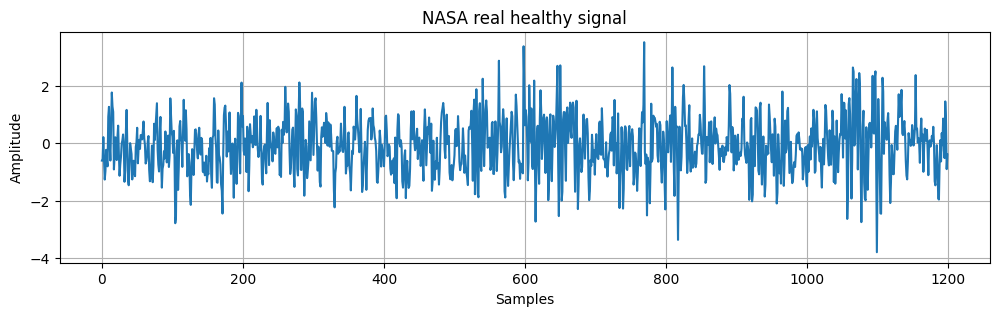

In [9]:
x = X_calibration[0].reshape(-1)

plt.figure(figsize=(12,3))
plt.plot(x)
plt.title("NASA real healthy signal")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.grid()

In [10]:
ae_stability_summary = (
    ae_results
    .groupby(
        [
            "experiment_id",
            "bearing_id",
            "detector",
        ],
        as_index=False,
    )
    .agg(
        threshold_mean=("threshold", "mean"),
        threshold_std=("threshold", "std"),

        calibration_exceedance_mean=(
            "calibration_exceedance_rate",
            "mean",
        ),
        calibration_exceedance_std=(
            "calibration_exceedance_rate",
            "std",
        ),

        monitoring_exceedance_mean=(
            "monitoring_exceedance_rate",
            "mean",
        ),
        monitoring_exceedance_std=(
            "monitoring_exceedance_rate",
            "std",
        ),

        alarm_detection_rate=(
            "persistent_departure_detected",
            "mean",
        ),

        alarm_index_mean=("alarm_index", "mean"),
        alarm_index_std=("alarm_index", "std"),

        lead_time_hours_mean=("lead_time_hours", "mean"),
        lead_time_hours_std=("lead_time_hours", "std"),

        lead_time_recordings_mean=(
            "lead_time_recordings",
            "mean",
        ),
        lead_time_recordings_std=(
            "lead_time_recordings",
            "std",
        ),

        epochs_mean=("epochs_trained", "mean"),
        epochs_std=("epochs_trained", "std"),
    )
)

ae_stability_summary["alarm_detection_rate"] *= 100.0

display(ae_stability_summary)

AttributeError: 'list' object has no attribute 'groupby'

### METHOD TEST

In [14]:
# =====================================================================
# TRAIN THE FIXED OEM / SHARED NASA SIMULATOR-TRAINED MODEL
# =====================================================================

from bearing_simulator import (
    BearingSignalSimulator,
    NASA_PARAMS,
)

# ---------------------------------------------------------------------
# Reproducibility
# ---------------------------------------------------------------------

OEM_SEED = 42

keras.backend.clear_session()
keras.utils.set_random_seed(OEM_SEED)
np.random.seed(OEM_SEED)
tf.random.set_seed(OEM_SEED)

try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass


# ---------------------------------------------------------------------
# Synthetic NASA simulator configuration
# ---------------------------------------------------------------------

shared_simulator = BearingSignalSimulator(
    NASA_PARAMS
)

#shared_sig_len = len(shared_simulator.t)
shared_sig_len = SIG_LEN # BECAUSE NASA IS 20KHZ


SYNTHETIC_REGIMES = [
    "healthy",
    "outer_race",
    "inner_race",
    "ball_fault",
]


SYNTHETIC_LABELS = {
    "healthy": 0,
    "outer_race": 1,
    "inner_race": 2,
    "ball_fault": 3,
}


N_SYNTHETIC_TRAIN = 4000
N_SYNTHETIC_VAL = 1000
N_SYNTHETIC_TEST = 750


SHARED_LATENT_DIM = 16
SHARED_THRESHOLD_PERCENTILE = 98.0


print(
    f"Shared NASA synthetic signal length: {shared_sig_len} samples"
)


# ---------------------------------------------------------------------
# Generate OEM healthy training and validation data
# ---------------------------------------------------------------------

def generate_oem_healthy(n):

    samples = []

    while len(samples) < n:

        signal = shared_simulator.sample(
            regime="healthy",
            mc=True,
            coverage="wide",
            asset_signature=np.random.uniform(
                0.8,
                1.2,
                5,
            ),
        )

        windows = make_windows(
            signal,
            win=SIG_LEN,
            step=STEP,
        )

        samples.extend(windows)

    return np.asarray(
        samples[:n],
        dtype=np.float32,
    )


def generate_oem_regime(n, regime):

    samples = []

    while len(samples) < n:

        signal = shared_simulator.sample(
            regime=regime,
            mc=True,
            coverage="wide",
            asset_signature=np.random.uniform(
                0.8,
                1.2,
                5,
            ),
        )

        windows = make_windows(
            signal,
            win=SIG_LEN,
            step=STEP,
        )

        samples.extend(windows)

    return np.asarray(
        samples[:n],
        dtype=np.float32,
    )

X_shared_train_raw = generate_oem_healthy(
    N_SYNTHETIC_TRAIN
)


X_shared_val_raw = generate_oem_healthy(
    N_SYNTHETIC_VAL
)


# ---------------------------------------------------------------------
# Preprocessing
# ---------------------------------------------------------------------

shared_scaler = StandardScaler()


X_shared_train_sc = shared_scaler.fit_transform(
    X_shared_train_raw
).astype(np.float32)


X_shared_val_sc = shared_scaler.transform(
    X_shared_val_raw
).astype(np.float32)


X_shared_train = X_shared_train_sc[..., np.newaxis]
X_shared_val = X_shared_val_sc[..., np.newaxis]


# ---------------------------------------------------------------------
# Independent synthetic NASA test set
# ---------------------------------------------------------------------

shared_test_by_regime = {}
shared_y_test_parts = []


for regime in SYNTHETIC_REGIMES:

    regime_raw = generate_oem_regime(
    N_SYNTHETIC_TEST,
    regime,
)


    regime_sc = shared_scaler.transform(
        regime_raw
    ).astype(np.float32)


    shared_test_by_regime[regime] = (
        regime_sc[..., np.newaxis]
    )


    shared_y_test_parts.append(
        np.full(
            N_SYNTHETIC_TEST,
            SYNTHETIC_LABELS[regime],
            dtype=np.int64,
        )
    )


X_shared_test = np.concatenate(
    [
        shared_test_by_regime[r]
        for r in SYNTHETIC_REGIMES
    ],
    axis=0,
)


y_shared_test = np.concatenate(
    shared_y_test_parts
)


print(
    f"Train: {X_shared_train.shape} | "
    f"Validation: {X_shared_val.shape} | "
    f"Test: {X_shared_test.shape}"
)


# ---------------------------------------------------------------------
# Build fixed OEM NASA AE
# ---------------------------------------------------------------------

shared_ae, shared_encoder = build_autoencoder(
    sig_len=shared_sig_len,
    latent_dim=SHARED_LATENT_DIM,
)


shared_ae.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-3
    ),
    loss="mse",
)


shared_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True,
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=5,
        min_lr=1e-6,
    ),
]


shared_history = shared_ae.fit(
    X_shared_train,
    X_shared_train,
    validation_data=(
        X_shared_val,
        X_shared_val,
    ),
    epochs=100,
    batch_size=32,
    shuffle=True,
    callbacks=shared_callbacks,
    verbose=1,
)

# ---------------------------------------------------------------------
# OEM threshold calibration
# ---------------------------------------------------------------------

X_shared_val_rec = shared_ae.predict(
    X_shared_val,
    verbose=0,
)


shared_val_mse = np.mean(
    np.square(
        X_shared_val - X_shared_val_rec
    ),
    axis=(1,2),
)


shared_tau_mc = float(
    np.percentile(
        shared_val_mse,
        SHARED_THRESHOLD_PERCENTILE,
    )
)


print(
    f"\nNASA synthetic OEM threshold "
    f"τ_MC(p{SHARED_THRESHOLD_PERCENTILE:.0f})"
    f" = {shared_tau_mc:.6f}"
)


# ---------------------------------------------------------------------
# Synthetic sanity evaluation
# ---------------------------------------------------------------------

X_shared_test_rec = shared_ae.predict(
    X_shared_test,
    verbose=0,
)


shared_test_mse = np.mean(
    np.square(
        X_shared_test - X_shared_test_rec
    ),
    axis=(1,2),
)


def synthetic_rate(regime):

    mask = (
        y_shared_test
        ==
        SYNTHETIC_LABELS[regime]
    )

    return (
        100
        *
        np.mean(
            shared_test_mse[mask]
            >
            shared_tau_mc
        )
    )


synthetic_ae_results = pd.DataFrame(
    [
        {
            "dataset": "NASA synthetic",
            "detector": "Shared NASA simulator-trained AE",
            "threshold": shared_tau_mc,
            "healthy_far": synthetic_rate("healthy"),
            "ball_dr": synthetic_rate("ball_fault"),
            "inner_race_dr": synthetic_rate("inner_race"),
            "outer_race_dr": synthetic_rate("outer_race"),
            "n_train": N_SYNTHETIC_TRAIN,
            "n_validation": N_SYNTHETIC_VAL,
        }
    ]
)


display(synthetic_ae_results)


# ---------------------------------------------------------------------
# Artifacts
# ---------------------------------------------------------------------

assert shared_ae is not None
assert shared_scaler is not None
assert np.isfinite(shared_tau_mc)


print("\nFixed NASA OEM artifacts created:")
print("  shared_ae")
print("  shared_encoder")
print("  shared_scaler")
print("  shared_tau_mc")
print("  shared_history")

print(X_shared_train_raw.shape)
print(X_shared_val_raw.shape)
print(regime_raw.shape)

Shared NASA synthetic signal length: 1200 samples
Train: (4000, 1200, 1) | Validation: (1000, 1200, 1) | Test: (3000, 1200, 1)
Epoch 1/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step - loss: 0.2315 - val_loss: 0.0540 - learning_rate: 0.0010
Epoch 2/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - loss: 0.0363 - val_loss: 0.0280 - learning_rate: 0.0010
Epoch 3/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - loss: 0.0243 - val_loss: 0.0217 - learning_rate: 0.0010
Epoch 4/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - loss: 0.0189 - val_loss: 0.0181 - learning_rate: 0.0010
Epoch 5/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - loss: 0.0163 - val_loss: 0.0150 - learning_rate: 0.0010
Epoch 6/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - loss: 0.0139 - val_loss: 0.0136 - learning_rate: 0.0010
Epoch 7/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - loss: 0.0136 - val_loss: 0.0179 - learning_rate: 0.0010
Epoch 8/100
125/125 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - loss: 0.0161 - val_loss: 0.0144 -

,dataset,detector,threshold,healthy_far,ball_dr,inner_race_dr,outer_race_dr,n_train,n_validation
0,NASA synthetic,Shared NASA simulator-trained AE,0.012016,1.333333,40.666667,98.4,88.666667,4000,1000



Fixed NASA OEM artifacts created:
  shared_ae
  shared_encoder
  shared_scaler
  shared_tau_mc
  shared_history
(4000, 1200)
(1000, 1200)
(750, 1200)


### DOMAIN ADAPTATION ###

In [34]:
WINDOW_SIZE = 100
TARGET_PERCENTILE = 98.0
WARMUP_SIZE = 100
MIN_WARMUP_SAMPLES = 20

# =====================================================================
# Online operational-radius estimator
# =====================================================================

class AdaptiveOperationalRadius:
    """
    Online empirical-quantile estimator.

    The globally shared quantity is the target nominal coverage
    (e.g. 98%), not a z-score or an absolute threshold.

    The local operational radius is estimated as the empirical
    percentile of the accepted nominal residuals.
    """

    def __init__(
        self,
        percentile=98.0,
        window_size=100,
        min_samples=20,
    ):
        if not 0.0 < percentile < 100.0:
            raise ValueError("percentile must be between 0 and 100.")

        if window_size < 2:
            raise ValueError("window_size must be at least 2.")

        if min_samples < 2:
            raise ValueError("min_samples must be at least 2.")

        if min_samples > window_size:
            raise ValueError(
                "min_samples cannot be larger than window_size."
            )

        self.percentile = float(percentile)
        self.window_size = int(window_size)
        self.min_samples = int(min_samples)

        self.buf = deque(maxlen=self.window_size)

    def update(self, mse_value):
        """
        Add one nominal residual and update the operational radius.

        Returns
        -------
        tau : float
            Current operational radius. NaN until min_samples is reached.
        """
        self.buf.append(float(mse_value))

        if len(self.buf) < self.min_samples:
            return np.nan

        arr = np.asarray(self.buf, dtype=np.float64)

        return float(
            np.percentile(
                arr,
                self.percentile,
            )
        )

    def warmup_trace(self, mse_sequence):
        """
        Process an entire warm-up sequence and return tau(t).
        """
        history_tau = []

        for mse_value in mse_sequence:
            history_tau.append(
                self.update(mse_value)
            )

        return np.asarray(history_tau, dtype=np.float64)


# =====================================================================
# Convergence utilities
# =====================================================================

def operational_radius_convergence_trace(
    tau_history,
    *,
    lookback=10,
    eps=1e-12,
):
    """
    Relative variation of tau over a fixed look-back interval.

    C(t) = |tau(t) - tau(t-L)| / max(|tau(t-L)|, eps)
    """
    tau_history = np.asarray(tau_history, dtype=np.float64)

    convergence = np.full(
        tau_history.shape,
        np.nan,
        dtype=np.float64,
    )

    for t in range(lookback, len(tau_history)):
        current = tau_history[t]
        previous = tau_history[t - lookback]

        if np.isfinite(current) and np.isfinite(previous):
            convergence[t] = (
                abs(current - previous)
                / max(abs(previous), eps)
            )

    return convergence


def find_convergence_index(
    tau_history,
    *,
    lookback=10,
    tolerance=0.01,
    consecutive=10,
):
    """
    Return the first index at which the operational radius remains
    stable for `consecutive` updates.

    Returns None when convergence is not observed.
    """
    convergence = operational_radius_convergence_trace(
        tau_history,
        lookback=lookback,
    )

    stable_count = 0

    for t, value in enumerate(convergence):
        if np.isfinite(value) and value < tolerance:
            stable_count += 1

            if stable_count >= consecutive:
                return t
        else:
            stable_count = 0

    return None


# =====================================================================
# Shared simulator-trained AE applied unchanged to NASA IMS
# =====================================================================

def run_nasa_experiment(
    bearing_id,
    *,
    target_percentile=TARGET_PERCENTILE,
    warmup_size=100,
    operational_window_size=WINDOW_SIZE,
    min_warmup_samples=MIN_WARMUP_SAMPLES,
    convergence_lookback=10,
    convergence_tolerance=0.01,
    convergence_consecutive=10,
):
    """
    Evaluate the fixed OEM/shared simulator-trained AE on one NASA IMS bearing.

    Deployment logic:
    - The AE and scaler are frozen OEM artifacts.
    - The first healthy recordings are used only for local calibration.
    - The remaining trajectory is monitored without retraining.
    """

    # ---------------------------------------------------------------
    # Load NASA bearing trajectory
    # ---------------------------------------------------------------

    run = load_nasa_run(
        experiment_id=2,
        bearing_id=bearing_id,
        data_root=data_root,
        sensor_index=0,
        warmup_recordings=100,
    )

    early_signal = run["early_signal"]
    monitoring_signal = run["monitoring_signal"]

    print(f"\nNASA IMS bearing: {bearing_id}")
    print("Early:", early_signal.shape)
    print("Monitoring:", monitoring_signal.shape)

    # ---------------------------------------------------------------
    # OEM absolute simulator threshold
    # ---------------------------------------------------------------

    X_train_rec = shared_ae.predict(
        X_shared_train,
        verbose=0,
    )


    mse_mc_healthy = np.mean(
    np.square(
        X_shared_train - X_shared_train_rec
    ),
    axis=(1,2),
)


    tau_mc = float(
        np.percentile(
            mse_mc_healthy,
            target_percentile,
        )
    )


    # ---------------------------------------------------------------
    # NASA residuals
    # ---------------------------------------------------------------

    mse_early = score_windows_mse(early_signal, ae=shared_ae, scaler=shared_scaler)
    mse_monitoring = score_windows_mse(monitoring_signal, ae=shared_ae, scaler=shared_scaler)


    print(
        "Windows → "
        f"early:{len(mse_early)} "
        f"monitoring:{len(mse_monitoring)}"
    )


    # ---------------------------------------------------------------
    # Offline oracle (only for analysis)
    # ---------------------------------------------------------------

    tau_field_oracle = float(
        np.percentile(
            mse_early,
            target_percentile,
        )
    )


    # ---------------------------------------------------------------
    # Online local operational-radius calibration
    # ---------------------------------------------------------------

    warmup_size = min(
        int(warmup_size),
        len(mse_early),
    )


    if warmup_size < min_warmup_samples:
        raise ValueError(
            f"warmup_size={warmup_size} "
            f"< min_warmup_samples={min_warmup_samples}"
        )


    mse_warmup = mse_early[
        :warmup_size
    ]


    adaptive = AdaptiveOperationalRadius(
        percentile=target_percentile,
        window_size=min(
            operational_window_size,
            warmup_size,
        ),
        min_samples=min(
            min_warmup_samples,
            warmup_size,
        ),
    )


    tau_history = adaptive.warmup_trace(
        mse_warmup
    )


    valid_tau = tau_history[
        np.isfinite(tau_history)
    ]


    if len(valid_tau) == 0:
        raise RuntimeError(
            "Operational radius was not initialized."
        )


    tau_online = float(
        valid_tau[-1]
    )


    convergence_index = find_convergence_index(
        tau_history,
        lookback=convergence_lookback,
        tolerance=convergence_tolerance,
        consecutive=convergence_consecutive,
    )


    # ---------------------------------------------------------------
    # Detection metrics
    # ---------------------------------------------------------------

    def alarm_rate(
        scores,
        threshold,
    ):
        return (
            100.0
            *
            float(
                np.mean(
                    scores > threshold
                )
            )
        )


    alarm_mask = mse_monitoring > tau_online

    if np.any(alarm_mask):
        first_alarm = np.argmax(alarm_mask)
    else:
        first_alarm = np.nan


    if not np.any(
        mse_monitoring > tau_online
    ):
        first_alarm = np.nan


    rows = []


    for name, threshold in {
        "absolute_mc": tau_mc,
        "field_oracle": tau_field_oracle,
        "online_radius": tau_online,
    }.items():


        monitoring_alarm = alarm_rate(
            mse_monitoring,
            threshold,
        )


        rows.append(
            {
                "bearing_id": str(bearing_id),
                "detector":
                    "Shared NASA simulator-trained AE",

                "calibration":
                    name,

                "threshold":
                    threshold,

                "early_far":
                    alarm_rate(
                        mse_early,
                        threshold,
                    ),

                "monitoring_alarm_rate":
                    monitoring_alarm,

                "alarm_index":
                    first_alarm,

                "monitoring_windows":
                    len(mse_monitoring),

                "warmup_size":
                    warmup_size,

                "convergence_index":
                    (
                        convergence_index
                        if name == "online_radius"
                        else np.nan
                    ),
            }
        )


    results_table = pd.DataFrame(
        rows
    )


    display(
        results_table
    )


    return {

        "bearing_id":
            str(bearing_id),

        "mse_mc_healthy":
            mse_mc_healthy,

        "mse_early":
            mse_early,

        "mse_monitoring":
            mse_monitoring,

        "mse_warmup":
            mse_warmup,

        "tau_history":
            tau_history,

        "tau_mc":
            tau_mc,

        "tau_field_oracle":
            tau_field_oracle,

        "tau_online":
            tau_online,

        "convergence_index":
            convergence_index,

        "alarm_index":
            first_alarm,

        "results_table":
            results_table,
    }

#### STABILITY

In [ ]:
# =====================================================================
# STABILITY UNDER LOCAL WARM-UP SAMPLING VARIABILITY
# Fixed OEM model; different 100-window field initialization samples
# =====================================================================

NASA_BEARING_IDS = [1, 2, 3, 4]
STABILITY_SEEDS = [7, 21, 42, 84, 126]

CONVERGENCE_LOOKBACK = 10
CONVERGENCE_TOLERANCE = 0.01
CONVERGENCE_CONSECUTIVE = 10

STEP = 1200

# ---------------------------------------------------------------------
# Sanity checks: the OEM artifacts must already exist
# ---------------------------------------------------------------------

required_objects = [
    "shared_ae",
    "shared_scaler",
    "shared_sig_len",
]

missing = [
    name for name in required_objects
    if name not in globals()
]

if missing:
    raise RuntimeError(
        "Missing fixed OEM artifacts: "
        + ", ".join(missing)
        + ". Run the shared-model training cell first."
    )


# ---------------------------------------------------------------------
# Helper: apply the fixed simulator-trained model to one field signal
# ---------------------------------------------------------------------

def shared_nasa_mse(signal):
    windows = make_windows(
        signal,
        win=shared_sig_len,
        step=STEP,
    ).astype(np.float32)

    windows_2d = windows.reshape(
        windows.shape[0],
        -1,
    )

    windows_scaled = shared_scaler.transform(
        windows_2d
    ).astype(np.float32)

    X = windows_scaled[..., np.newaxis]

    X_rec = shared_ae.predict(
        X,
        verbose=0,
    )

    return np.mean(
        np.square(X - X_rec),
        axis=(1, 2),
    )


# ---------------------------------------------------------------------
# Compute field residuals once.
# These do not change across stability seeds.
# ---------------------------------------------------------------------

field_residuals = {}

for bearing_id in NASA_BEARING_IDS:

    print(
        f"Computing fixed-model residuals for NASA bearing {bearing_id}..."
    )

    run = load_nasa_run(
        experiment_id=2,
        bearing_id=bearing_id,
        data_root=data_root,
        sensor_index=0,
        warmup_recordings=100,
    )

    early_signal = run["early_signal"]
    monitoring_signal = run["monitoring_signal"]

    field_residuals[str(bearing_id)] = {
        "early": shared_nasa_mse(
            early_signal
        ),
        "monitoring": shared_nasa_mse(
            monitoring_signal
        ),
    }


# ---------------------------------------------------------------------
# Stability experiment
# ---------------------------------------------------------------------

warmup_stability_rows = []
warmup_traces = {}

for seed in STABILITY_SEEDS:

    print("\n" + "=" * 60)
    print(f"Warm-up sampling seed: {seed}")
    print("=" * 60)

    for bearing_id in BEARING_IDS:

        bearing_key = str(bearing_id)
        residuals = field_residuals[bearing_key]

        healthy_scores = residuals["early"]
        monitoring_scores = residuals["monitoring"]

        n_healthy = len(healthy_scores)

        if WARMUP_SIZE >= n_healthy:
            raise ValueError(
                f"{bearing_id}: WARMUP_SIZE={WARMUP_SIZE} must be "
                f"smaller than n_healthy={n_healthy} so that an "
                "independent healthy test set remains."
            )

        # Bearing-specific generator: reproducible but independent
        # across RPM conditions.
        rng = np.random.default_rng(
            seed + int(bearing_id)
        )

        # Random permutation determines both the selected observations
        # and the order in which they arrive during initialization.
        permutation = rng.permutation(n_healthy)

        warmup_indices = permutation[:WARMUP_SIZE]
        healthy_test_indices = permutation[WARMUP_SIZE:]

        warmup_scores = healthy_scores[warmup_indices]
        healthy_test_scores = healthy_scores[healthy_test_indices]

        # -------------------------------------------------------------
        # Sequential local-radius estimation
        # -------------------------------------------------------------

        adaptive = AdaptiveOperationalRadius(
            percentile=TARGET_PERCENTILE,
            window_size=WARMUP_SIZE,
            min_samples=MIN_WARMUP_SAMPLES,
        )

        tau_history = adaptive.warmup_trace(
            warmup_scores
        )

        valid_tau = tau_history[
            np.isfinite(tau_history)
        ]

        if len(valid_tau) == 0:
            raise RuntimeError(
                f"{bearing_id}, seed {seed}: "
                "the local radius did not initialize."
            )

        tau_online = float(valid_tau[-1])

        convergence_index = find_convergence_index(
            tau_history,
            lookback=CONVERGENCE_LOOKBACK,
            tolerance=CONVERGENCE_TOLERANCE,
            consecutive=CONVERGENCE_CONSECUTIVE,
        )

        # Complete-data field oracle, used only as a reference.
        tau_field_oracle = float(
            np.percentile(
                healthy_scores,
                TARGET_PERCENTILE,
            )
        )

        threshold_absolute_error = abs(
            tau_online - tau_field_oracle
        )

        threshold_relative_error_pct = (
            100.0
            * threshold_absolute_error
            / max(abs(tau_field_oracle), 1e-12)
        )

        def alarm_rate(scores):
            return 100.0 * float(
                np.mean(scores > tau_online)
            )

        row = {
            "bearing_id": bearing_key,
            "seed": seed,
            "detector": "Fixed shared simulator-trained AE",
            "calibration": "random_100_window_online_radius",
            "threshold_percentile": TARGET_PERCENTILE,

            "tau_online": tau_online,
            "tau_field_oracle": tau_field_oracle,
            "tau_absolute_error": threshold_absolute_error,
            "tau_relative_error_pct": threshold_relative_error_pct,

            # FAR is evaluated only on healthy windows not used
            # for local calibration.
            "healthy_far": alarm_rate(
                healthy_test_scores
            ),
            #"ball_dr": alarm_rate(
            #    ball_scores
            #),
            #"inner_race_dr": alarm_rate(
            #    inner_scores
            #),
            #"outer_race_dr": alarm_rate(
            #    outer_scores
            #),

            "warmup_size": len(warmup_scores),
            "n_healthy_test": len(healthy_test_scores),
            #"n_ball": len(ball_scores),
            #"n_inner_race": len(inner_scores),
            #"n_outer_race": len(outer_scores),

            # Convert zero-based Python index to window count.
            "convergence_window": (
                convergence_index + 1
                if convergence_index is not None
                else np.nan
            ),
        }

        warmup_stability_rows.append(row)

        warmup_traces[(bearing_key, seed)] = {
            "warmup_indices": warmup_indices,
            "healthy_test_indices": healthy_test_indices,
            "warmup_scores": warmup_scores,
            "tau_history": tau_history,
            "tau_online": tau_online,
            "tau_field_oracle": tau_field_oracle,
            "convergence_index": convergence_index,
        }

        print(
            f"{bearing_id} RPM | "
            f"tau={tau_online:.6f} | "
            f"oracle={tau_field_oracle:.6f} | "
            f"FAR={row['healthy_far']:.2f}% | "
            #f"Ball={row['ball_dr']:.2f}% | "
            f"Conv={row['convergence_window']}"
        )


# ---------------------------------------------------------------------
# Long-form result table: one row per RPM and seed
# ---------------------------------------------------------------------

warmup_stability_results = pd.DataFrame(
    warmup_stability_rows
)

display(warmup_stability_results)


# ---------------------------------------------------------------------
# Summary by operating condition
# ---------------------------------------------------------------------

warmup_stability_by_bearing = (
    warmup_stability_results
    .groupby("bearing_id")
    .agg(
        tau_online_mean=("tau_online", "mean"),
        tau_online_std=("tau_online", "std"),

        tau_relative_error_mean=(
            "tau_relative_error_pct",
            "mean",
        ),
        tau_relative_error_std=(
            "tau_relative_error_pct",
            "std",
        ),

        healthy_far_mean=("healthy_far", "mean"),
        healthy_far_std=("healthy_far", "std"),

        convergence_mean=("convergence_window", "mean"),
        convergence_std=("convergence_window", "std"),
    )
    .reset_index()
)

display(warmup_stability_by_bearing)


# ---------------------------------------------------------------------
# Global stability across seeds
#
# First average the four RPM conditions within each seed. Then calculate
# variability across seeds, avoiding the conflation of RPM heterogeneity
# with warm-up sampling variability.
# ---------------------------------------------------------------------

warmup_seed_means = (
    warmup_stability_results
    .groupby("seed")[
        [
            "healthy_far",
            "tau_relative_error_pct",
            "convergence_window",
        ]
    ]
    .mean()
)

display(warmup_seed_means)

warmup_global_summary = pd.DataFrame(
    {
        "mean": warmup_seed_means.mean(),
        "std": warmup_seed_means.std(ddof=1),
        "min": warmup_seed_means.min(),
        "max": warmup_seed_means.max(),
    }
)

display(warmup_global_summary)

Computing fixed-model residuals for NASA bearing 1...
Computing fixed-model residuals for NASA bearing 2...
Computing fixed-model residuals for NASA bearing 3...
Computing fixed-model residuals for NASA bearing 4...

Warm-up sampling seed: 7
1 RPM | tau=0.012182 | oracle=0.012083 | FAR=1.56% | Conv=43
2 RPM | tau=0.016457 | oracle=0.016829 | FAR=3.92% | Conv=39
3 RPM | tau=0.020900 | oracle=0.020360 | FAR=1.00% | Conv=71
4 RPM | tau=0.007424 | oracle=0.007523 | FAR=2.99% | Conv=39

Warm-up sampling seed: 21
1 RPM | tau=0.012158 | oracle=0.012083 | FAR=1.74% | Conv=57
2 RPM | tau=0.016457 | oracle=0.016829 | FAR=3.92% | Conv=39
3 RPM | tau=0.020944 | oracle=0.020360 | FAR=0.81% | Conv=92
4 RPM | tau=0.007388 | oracle=0.007523 | FAR=3.49% | Conv=61

Warm-up sampling seed: 42
1 RPM | tau=0.012008 | oracle=0.012083 | FAR=2.49% | Conv=44
2 RPM | tau=0.016506 | oracle=0.016829 | FAR=3.74% | Conv=39
3 RPM | tau=0.020175 | oracle=0.020360 | FAR=2.55% | Conv=39
4 RPM | tau=0.007329 | oracle=0.0

,bearing_id,seed,detector,calibration,threshold_percentile,tau_online,tau_field_oracle,tau_absolute_error,tau_relative_error_pct,healthy_far,warmup_size,n_healthy_test,convergence_window
0,1,7,Fixed shared simulator-trained AE,random_100_window_online_radius,98.0,0.012182,0.012083,0.000099,0.819188,1.556663,100,1606,43
1,2,7,Fixed shared simulator-trained AE,random_100_window_online_radius,98.0,0.016457,0.016829,0.000372,2.212068,3.922790,100,1606,39
2,3,7,Fixed shared simulator-trained AE,random_100_window_online_radius,98.0,0.020900,0.020360,0.000540,2.652983,0.996264,100,1606,71
3,4,7,Fixed shared simulator-trained AE,random_100_window_online_radius,98.0,0.007424,0.007523,0.000099,1.310045,2.988792,100,1606,39
4,1,21,Fixed shared simulator-trained AE,random_100_window_online_radius,98.0,0.012158,0.012083,0.000075,0.618819,1.743462,100,1606,57
5,2,21,Fixed shared simulator-trained AE,random_100_window_online_radius,98.0,0.016457,0.016829,0.000372,2.211271,3.922790,100,1606,39
6,3,21,Fixed shared simulator-trained AE,random_100_window_online_radius,98.0,0.020944,0.020360,0.000584,2.870346,0.809465,100,1606,92
7,4,21,Fixed shared simulator-trained AE,random_100_window_online_radius,98.0,0.007388,0.007523,0.000135,1.791920,3.486924,100,1606,61
8,1,42,Fixed shared simulator-trained AE,random_100_window_online_radius,98.0,0.012008,0.012083,0.000075,0.620672,2.490660,100,1606,44
9,2,42,Fixed shared simulator-trained AE,random_100_window_online_radius,98.0,0.016506,0.016829,0.000323,1.919999,3.735990,100,1606,39


KeyError: "Column(s) ['ball_dr', 'inner_race_dr', 'outer_race_dr'] do not exist"

In [ ]:
# =====================================================================
# EDGE FOOTPRINT MEASUREMENT
# Requires: shared_ae, shared_sig_len
# =====================================================================

import os
import time
import tempfile


# ---------------------------------------------------------------------
# 1. Parameter and raw-weight size
# ---------------------------------------------------------------------

parameter_count = shared_ae.count_params()

float32_weight_bytes = parameter_count * np.dtype(np.float32).itemsize
float32_weight_mb = float32_weight_bytes / 1_000_000
float32_weight_mib = float32_weight_bytes / (1024 ** 2)


# ---------------------------------------------------------------------
# 2. Exact serialized model size
# Save without optimizer state, because deployment uses inference only.
# ---------------------------------------------------------------------

with tempfile.TemporaryDirectory() as tmpdir:
    keras_path = os.path.join(tmpdir, "shared_oem_model.keras")

    # Clone/compile state is not required for inference.
    shared_ae.save(
        keras_path,
        include_optimizer=False,
    )

    serialized_bytes = os.path.getsize(keras_path)
    serialized_mb = serialized_bytes / 1_000_000
    serialized_mib = serialized_bytes / (1024 ** 2)


# ---------------------------------------------------------------------
# 3. Local calibration-state size
# Compact implementation: 100 float32 residuals plus a few scalar values.
# ---------------------------------------------------------------------

LOCAL_BUFFER_LENGTH = 100

residual_buffer_bytes = (
    LOCAL_BUFFER_LENGTH * np.dtype(np.float32).itemsize
)

# Example compact scalar state:
# current tau, previous tau, percentile, tolerance,
# convergence counter, state flag, and sample counter.
estimated_scalar_state_bytes = (
    4 * np.dtype(np.float32).itemsize
    + 3 * np.dtype(np.int32).itemsize
)

local_state_bytes = (
    residual_buffer_bytes + estimated_scalar_state_bytes
)


# ---------------------------------------------------------------------
# 4. Batch-1 CPU inference latency
# Use a real-shaped input. shared_ae is kept fixed.
# ---------------------------------------------------------------------

benchmark_input = np.zeros(
    (1, shared_sig_len, 1),
    dtype=np.float32,
)

benchmark_tensor = tf.convert_to_tensor(benchmark_input)

# Warm-up: TensorFlow tracing, memory allocation, and caches
N_WARMUP = 50
for _ in range(N_WARMUP):
    _ = shared_ae(
        benchmark_tensor,
        training=False,
    )

# Timed runs
N_RUNS = 500
latencies_ms = []

for _ in range(N_RUNS):
    start = time.perf_counter()

    output = shared_ae(
        benchmark_tensor,
        training=False,
    )

    # Force completion before stopping the clock
    _ = output.numpy()

    elapsed_ms = (
        time.perf_counter() - start
    ) * 1000.0

    latencies_ms.append(elapsed_ms)

latencies_ms = np.asarray(latencies_ms)

latency_median_ms = float(np.median(latencies_ms))
latency_mean_ms = float(np.mean(latencies_ms))
latency_std_ms = float(np.std(latencies_ms, ddof=1))
latency_p95_ms = float(np.percentile(latencies_ms, 95))


# ---------------------------------------------------------------------
# 5. Results
# ---------------------------------------------------------------------

edge_footprint = pd.DataFrame(
    [
        {
            "metric": "Model parameters",
            "value": f"{parameter_count:,}",
        },
        {
            "metric": "Raw float32 weight size",
            "value": (
                f"{float32_weight_mb:.2f} MB "
                f"({float32_weight_mib:.2f} MiB)"
            ),
        },
        {
            "metric": "Serialized .keras size",
            "value": (
                f"{serialized_mb:.2f} MB "
                f"({serialized_mib:.2f} MiB)"
            ),
        },
        {
            "metric": "CPU latency, median",
            "value": f"{latency_median_ms:.3f} ms/window",
        },
        {
            "metric": "CPU latency, mean ± std",
            "value": (
                f"{latency_mean_ms:.3f} ± "
                f"{latency_std_ms:.3f} ms/window"
            ),
        },
        {
            "metric": "CPU latency, p95",
            "value": f"{latency_p95_ms:.3f} ms/window",
        },
        {
            "metric": "Local residual-buffer length",
            "value": str(LOCAL_BUFFER_LENGTH),
        },
        {
            "metric": "Residual-buffer memory",
            "value": f"{residual_buffer_bytes} bytes",
        },
        {
            "metric": "Estimated compact local state",
            "value": (
                f"{local_state_bytes} bytes "
                f"(< 1 kB)"
            ),
        },
        {
            "metric": "Per-asset model training",
            "value": "None",
        },
        {
            "metric": "Fault labels required",
            "value": "None",
        },
    ]
)

display(edge_footprint)